In [1]:
import os
import json
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import sem

In [2]:
data_table = pq.read_table('../../results/Dwivedi2024EEG/resnet50_t=15_gs=224_b5a83435/eval_df_rsa.parquet', partitioning=None)
df = data_table.to_pandas()

In [3]:
all_models = []
results_dir = '../../results/Dwivedi2024EEG/'
results_list = os.listdir(results_dir)
for dir in results_list:
    if dir == "model_comparison":
        continue
    data_table = pq.read_table(results_dir + dir + "/eval_df_rsa.parquet", partitioning=None)
    meta = data_table.schema.metadata["custom_meta".encode()]
    meta = json.loads(meta)
    df = data_table.to_pandas()

    df["model_name"] = meta["name"]
    df["time_window"] = int(meta["time_window"]) if meta["time_window"] !='None' else pd.NA
    df["crop_size"] = int(meta["crop_size"]) if meta["crop_size"] !='None' else pd.NA
    df["center_crop"] = meta["center_crop"] if isinstance(meta["center_crop"], bool) else pd.NA
    all_models.append(df)

all_models = pd.concat(all_models)

In [4]:
all_models = all_models.reset_index(drop=True)

In [5]:
all_models.head(10)

,ROI,Layer,Model,R,%R,R_array,Significance,SEM,LNC,UNC,model_name,time_window,crop_size,center_crop
0,eeg_rdms_decoding,backbone.layer1,resnet50_t=15_gs=540_b51b1a05,"[0.046745596774248915, -0.014804036548319017, ...","[9.717144402771938, -3.0773585280908136, 1.693...","[[0.09993633125090756, -0.006543269458488765, ...","[0.07412374671680011, 0.35962816274536813, 0.6...","[0.024350712702682284, 0.015665472964829032, 0...",0.481063,0.558464,resnet50,15,540,False
1,eeg_rdms_decoding,backbone.layer2,resnet50_t=15_gs=540_b51b1a05,"[0.04692075465992243, -0.015202282605058685, 0...","[9.753554986566462, -3.1601431047828727, 2.397...","[[0.07971871456345582, -0.03174810114947482, 0...","[0.050799217046989316, 0.3250823838153405, 0.5...","[0.022100581937324077, 0.014941934462952762, 0...",0.481063,0.558464,resnet50,15,540,False
2,eeg_rdms_decoding,backbone.layer3,resnet50_t=15_gs=540_b51b1a05,"[0.04420994719167081, -0.0011519900521459504, ...","[9.190051481748132, -0.23946755330387662, 5.51...","[[0.052693349046653855, -0.019169083965375897,...","[0.04695547165454301, 0.9334841717491567, 0.10...","[0.020424018991445844, 0.013572975712545305, 0...",0.481063,0.558464,resnet50,15,540,False
3,eeg_rdms_decoding,backbone.layer4,resnet50_t=15_gs=540_b51b1a05,"[0.03542077277126747, 0.004539850199852348, 0....","[7.363019998191234, 0.9437119857932783, 5.2243...","[[0.003815078506438929, -0.02055016660774511, ...","[0.08969641937067742, 0.6609091665093374, 0.10...","[0.019524131930234907, 0.01014492973361432, 0....",0.481063,0.558464,resnet50,15,540,False
4,eeg_rdms_decoding,backbone.layer1,resnet50_t=0_gs=112_50cbe6f8,"[0.07022822967973545, -0.0057836378765713185, ...","[14.598548227861151, -1.2022617807490332, 1.37...","[[0.16102489771805711, 0.007513461680468498, 0...","[0.010726293001101768, 0.7242607060286638, 0.7...","[0.024115317829251963, 0.016089763868422237, 0...",0.481063,0.558464,resnet50,0,112,False
5,eeg_rdms_decoding,backbone.layer2,resnet50_t=0_gs=112_50cbe6f8,"[0.062291992604114506, 0.006410962919221878, 0...","[12.94881933358969, 1.3326656786038276, 1.5335...","[[0.11692338050735375, 0.002526402383915132, 0...","[0.0003086140666552127, 0.5428036729531363, 0....","[0.013369707771116695, 0.010294662891174682, 0...",0.481063,0.558464,resnet50,0,112,False
6,eeg_rdms_decoding,backbone.layer3,resnet50_t=0_gs=112_50cbe6f8,"[0.0320324647212958, 0.005969255629912368, 0.0...","[6.658682458943327, 1.2408466879359852, 3.5008...","[[0.04142433638892538, -0.029594813702601648, ...","[0.013977578166104421, 0.5749696734885112, 0.2...","[0.011517173301483627, 0.010413008767343787, 0...",0.481063,0.558464,resnet50,0,112,False
7,eeg_rdms_decoding,backbone.layer4,resnet50_t=0_gs=112_50cbe6f8,"[0.03990131555353726, 0.007383898839808459, 0....","[8.29440357702057, 1.5349127240451585, 5.97746...","[[0.02472050606085635, 0.012003621047871286, -...","[0.010926950374579457, 0.6931473169066241, 0.1...","[0.01374463330558065, 0.01835481384546534, 0.0...",0.481063,0.558464,resnet50,0,112,False
8,eeg_rdms_decoding,backbone.layer1,resnet50_t=15_gs=224_b5a83435,"[0.053469286000037405, -0.013556878968684283, ...","[11.114817416593429, -2.8181082215250792, 1.88...","[[0.10975121550863401, -0.007885747248267627, ...","[0.040792283218864266, 0.4063911443970324, 0.6...","[0.023888117854649758, 0.015869504701729292, 0...",0.481063,0.558464,resnet50,15,224,False
9,eeg_rdms_decoding,backbone.layer2,resnet50_t=15_gs=224_b5a83435,"[0.05082906453018109, -0.014280995250408223, 0...","[10.565986830435941, -2.9686323983345186, 1.68...","[[0.1026838915045571, -0.02938927053540972, 0....","[0.027346794453599707, 0.3753017597597088, 0.6...","[0.02079509794364603, 0.01562897449110181, 0.0...",0.481063,0.558464,resnet50,15,224,False


In [6]:
all_models["subj_mean"] = all_models["R_array"].apply(list).apply(lambda x: np.mean(x,axis=0))
all_models["subj_sem"] = all_models["R_array"].apply(list).apply(lambda x: sem(x,axis=0))
#eeg_time = list(np.repeat(np.arange(100)[:,np.newaxis], len(all_models), axis=1).T)
#all_models["eeg_time"] = eeg_time
#all_models = all_models.explode(["eeg_time", "subj_mean"])
#all_models = all_models.reset_index(drop=True)

In [7]:
grouping = all_models.groupby(["model_name","Layer"])[["subj_mean", "subj_sem"]].agg(np.mean)

/tmp/ipykernel_1787498/3252719611.py:1: FutureWarning: The provided callable <function mean at 0x7b55d4124ca0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  grouping = all_models.groupby(["model_name","Layer"])[["subj_mean", "subj_sem"]].agg(np.mean)


In [8]:
grouping["eeg_time"] = list(np.repeat(np.arange(100)[:,np.newaxis], len(grouping), axis=1).T)

In [9]:
grouping = grouping.reset_index()

In [10]:
grouping=grouping.explode(["subj_mean", "subj_sem", "eeg_time"])

/home/yvette/.conda/envs/net2brain_env_editable/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/yvette/.conda/envs/net2brain_env_editable/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/yvette/.conda/envs/net2brain_env_editable/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/yvette/.conda/envs/net2brain_env_editable/lib/p

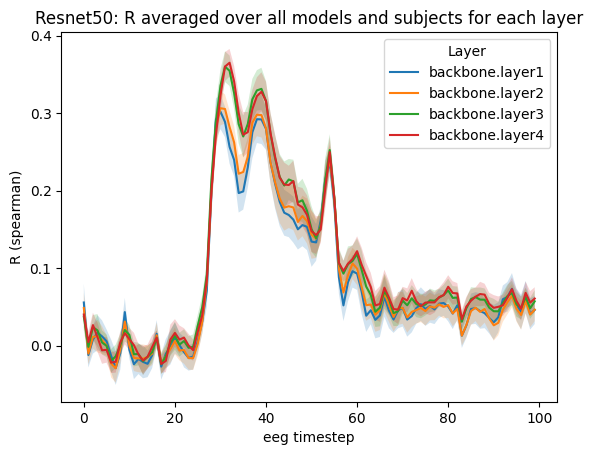

In [36]:
resnet_50_df = grouping.loc[grouping["model_name"]=="resnet50",:]
sns.lineplot(data=resnet_50_df, x="eeg_time", y="subj_mean", hue="Layer")
for layer in resnet_50_df["Layer"].unique():
    mean = resnet_50_df.loc[resnet_50_df["Layer"]==layer,"subj_mean"].to_numpy().astype('float64')
    sem = resnet_50_df.loc[resnet_50_df["Layer"]==layer,"subj_sem"].to_numpy().astype('float64')
    plt.fill_between(np.arange(100),np.array(mean-sem), np.array(mean+sem), alpha=0.2)

plt.xlabel("eeg timestep")
plt.ylabel("R (spearman)")
plt.title("Resnet50: R averaged over all models and subjects for each layer")
plt.savefig("../../results/Dwivedi2024EEG/model_comparison/resnet50_average_R_per_layer.pdf", format="PDF")

/tmp/ipykernel_1737126/3330376335.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vit_base_df["Layer"]=vit_base_df["Layer"].str.split(".").apply(lambda x: x[-1]).to_numpy().astype("int32")
/home/yvette/.conda/envs/net2brain_env_editable/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/yvette/.conda/envs/net2brain_env_editable/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_

Text(0.5, 1.0, 'ViT: R averaged over all models and subjects for each layer')

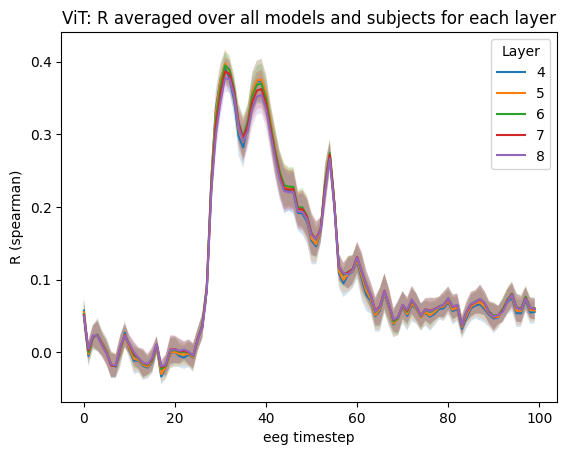

In [39]:
vit_base_df = grouping.loc[grouping["model_name"]=="vit_base",:]
vit_base_df["Layer"]=vit_base_df["Layer"].str.split(".").apply(lambda x: x[-1]).to_numpy().astype("int32")
#vit_base_df=vit_base_df.sort_values("Layer",axis=0)
vit_base_df = vit_base_df.loc[vit_base_df["Layer"].isin([4, 5, 6, 7, 8]),:]
sns.lineplot(data=vit_base_df, x="eeg_time", y="subj_mean", hue="Layer", palette='tab10')
for layer in vit_base_df["Layer"].unique():
    mean = vit_base_df.loc[vit_base_df["Layer"]==layer,"subj_mean"].to_numpy().astype('float64')
    sem = vit_base_df.loc[vit_base_df["Layer"]==layer,"subj_sem"].to_numpy().astype('float64')
    plt.fill_between(np.arange(100),np.array(mean-sem), np.array(mean+sem), alpha=0.2)

plt.xlabel("eeg timestep")
plt.ylabel("R (spearman)")
plt.title("ViT: R averaged over all models and subjects for each layer")
#plt.savefig("../../results/Dwivedi2024EEG/model_comparison/vit_base_average_R_per_layer.pdf", format="PDF")

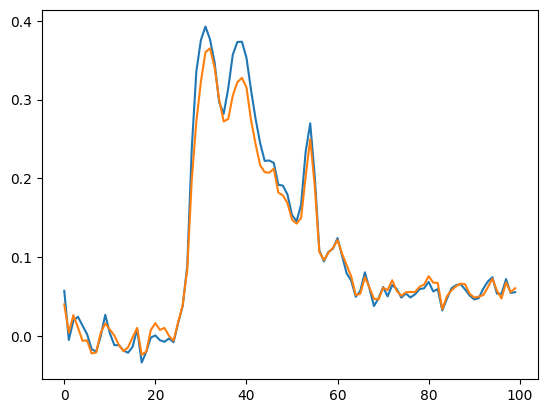

In [199]:
plt.plot(vit_base_df.loc[vit_base_df["Layer"]==4,"subj_mean"].to_numpy())
plt.plot(resnet_50_df.loc[resnet_50_df["Layer"]=="backbone.layer4","subj_mean"].to_numpy())

In [7]:
all_models["peak"] = all_models["subj_mean"].apply(np.max)

max_layers = all_models.groupby("Model")["peak"].idxmax()

In [8]:
#which_layers = pd.DataFrame(max_layers)
which_layers = all_models.loc[max_layers.to_numpy(),["Model", "Layer", "subj_mean", "subj_sem", "time_window", "crop_size", "center_crop", "model_name"]]

In [12]:
table_for_pres = which_layers[["model_name", "time_window", "crop_size", "center_crop", "Layer"]]
table_for_pres["Layer"]=table_for_pres["Layer"].apply(lambda x: x[-1])

/tmp/ipykernel_2490984/4139614520.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  table_for_pres["Layer"]=table_for_pres["Layer"].apply(lambda x: x[-1])


In [21]:
table_for_pres

,model_name,time_window,crop_size,center_crop,Layer
41,ResNet50,<NA>,<NA>,<NA>,4
6,resnet50,0,112,False,3
100,resnet50,0,224,False,3
45,resnet50,0,540,False,4
75,resnet50,10,224,False,4
114,resnet50,15,112,False,2
176,resnet50,15,224,True,4
11,resnet50,15,224,False,4
172,resnet50,15,336,False,4
48,resnet50,15,448,False,3


In [15]:
test_540 = all_models.loc[(all_models["model_name"]=="vit_base") & (all_models["time_window"]==0) & (all_models["crop_size"]==540),:]
test_540

,ROI,Layer,Model,R,%R,R_array,Significance,SEM,LNC,UNC,model_name,time_window,crop_size,center_crop,subj_mean,subj_sem,peak
143,eeg_rdms_decoding,backbone.blocks.1,vit_base_t=0_gs=540_f69cd5f1,"[0.06104989283583533, -0.0005464208400828857, ...","[12.690620409115436, -0.11358610380805573, 4.5...","[[0.15096047243212626, -0.00462089604107826, 0...","[0.011569122224337418, 0.9712044582875938, 0.1...","[0.021235695640892522, 0.014886930146030066, 0...",0.481063,0.558464,vit_base,0,540,False,"[0.06104989283583533, -0.0005464208400828857, ...","[0.021235695640892522, 0.014886930146030066, 0...",0.403106
144,eeg_rdms_decoding,backbone.blocks.2,vit_base_t=0_gs=540_f69cd5f1,"[0.06086219763268548, -0.0005128819364953395, ...","[12.65160365633928, -0.10661427348049077, 4.22...","[[0.14214118905746803, -0.01690718180002471, 0...","[0.01035203199060804, 0.9739429011906819, 0.22...","[0.020774346558550566, 0.015442348141398948, 0...",0.481063,0.558464,vit_base,0,540,False,"[0.06086219763268548, -0.0005128819364953395, ...","[0.020774346558550566, 0.015442348141398948, 0...",0.386005
145,eeg_rdms_decoding,backbone.blocks.3,vit_base_t=0_gs=540_f69cd5f1,"[0.06011505461999402, -0.0015282861735606127, ...","[12.496292845378697, -0.3176893325154658, 4.35...","[[0.1306346286745538, -0.0358625693108097, 0.0...","[0.012414599597561679, 0.9224208334952109, 0.2...","[0.021167136361129435, 0.01543157074870901, 0....",0.481063,0.558464,vit_base,0,540,False,"[0.06011505461999402, -0.0015282861735606127, ...","[0.021167136361129435, 0.01543157074870901, 0....",0.370253
146,eeg_rdms_decoding,backbone.blocks.4,vit_base_t=0_gs=540_f69cd5f1,"[0.058072394609677266, -0.0005021781593105186,...","[12.071679113696705, -0.10438924790081311, 4.9...","[[0.12435471252319674, -0.04151954345017389, 0...","[0.019362492744092803, 0.9743195792793063, 0.1...","[0.022175698762179563, 0.015341934575013, 0.01...",0.481063,0.558464,vit_base,0,540,False,"[0.058072394609677266, -0.0005021781593105186,...","[0.022175698762179563, 0.015341934575013, 0.01...",0.374527
147,eeg_rdms_decoding,backbone.blocks.5,vit_base_t=0_gs=540_f69cd5f1,"[0.05126523561003843, 0.0013372177010263493, 0...","[10.656654992995831, 0.2779713683316118, 5.115...","[[0.10791260264621792, -0.04205359520312326, 0...","[0.0340404503996052, 0.9316143298557318, 0.161...","[0.02198233064539714, 0.015323451712787681, 0....",0.481063,0.558464,vit_base,0,540,False,"[0.05126523561003843, 0.0013372177010263493, 0...","[0.02198233064539714, 0.015323451712787681, 0....",0.372426
148,eeg_rdms_decoding,backbone.blocks.6,vit_base_t=0_gs=540_f69cd5f1,"[0.045880724292080614, 0.0016488462464673936, ...","[9.5373608214477, 0.34275050872210383, 5.33737...","[[0.08990508754550368, -0.049255886686335945, ...","[0.049935820569887074, 0.9180345638579638, 0.1...","[0.021518737522485225, 0.015754758016057625, 0...",0.481063,0.558464,vit_base,0,540,False,"[0.045880724292080614, 0.0016488462464673936, ...","[0.021518737522485225, 0.015754758016057625, 0...",0.356503
149,eeg_rdms_decoding,backbone.blocks.7,vit_base_t=0_gs=540_f69cd5f1,"[0.04363753677828511, 0.0023311066524509855, 0...","[9.071062849056565, 0.4845739817917316, 4.8443...","[[0.08116590754946067, -0.05413279333955551, 0...","[0.06450012726462459, 0.8782642296648457, 0.17...","[0.021869828969492185, 0.014961701686339998, 0...",0.481063,0.558464,vit_base,0,540,False,"[0.04363753677828511, 0.0023311066524509855, 0...","[0.021869828969492185, 0.014961701686339998, 0...",0.354932
150,eeg_rdms_decoding,backbone.blocks.8,vit_base_t=0_gs=540_f69cd5f1,"[0.042517761565647225, 0.005370359026587871, 0...","[8.838291888993838, 1.1163522932031829, 4.9040...","[[0.07425566544800247, -0.05831606323047945, 0...","[0.06997941764695943, 0.718760216603384, 0.154...","[0.021791685116908495, 0.014633968238302658, 0...",0.481063,0.558464,vit_base,0,540,False,"[0.042517761565647225, 0.005370359026587871, 0...","[0.021791685116908495, 0.014633968238302658, 0...",0.344581
151,eeg_rdms_decoding,backbo

/tmp/ipykernel_1737126/1610537829.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered["eeg_time"] = list(np.repeat(np.arange(100)[:,np.newaxis], len(filtered), axis=1).T)
/home/yvette/.conda/envs/net2brain_env_editable/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/yvette/.conda/envs/net2brain_env_editable/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode

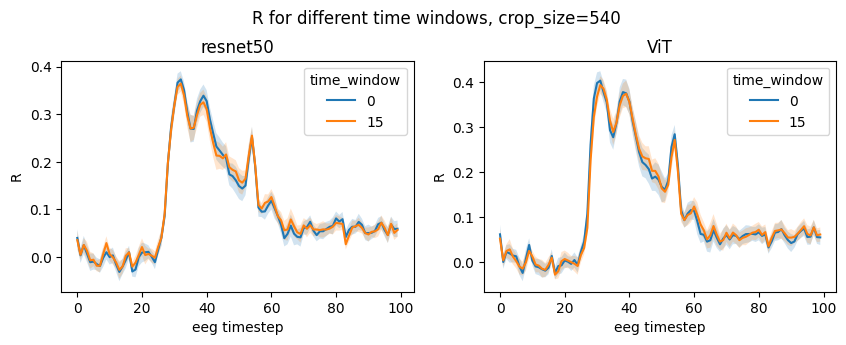

In [87]:
filtered = which_layers.loc[(which_layers["crop_size"]==540) & (which_layers["center_crop"]==False),:]
filtered["eeg_time"] = list(np.repeat(np.arange(100)[:,np.newaxis], len(filtered), axis=1).T)
filtered = filtered.explode(["subj_mean", "subj_sem", "eeg_time"])
#g = sns.FacetGrid(data=filtered, col="model_name", height=4, aspect=1.4)
fig, axs = plt.subplots(1,2, figsize=(10,3))
filtered_resnet50 = filtered.loc[filtered["model_name"]=="resnet50",:]
filtered_vit_base = filtered.loc[filtered["model_name"]=="vit_base",:]
sns.lineplot(data=filtered_resnet50, x="eeg_time", y="subj_mean", hue="time_window", palette="tab10", ax = axs[0])
sns.lineplot(data=filtered_vit_base, x="eeg_time", y="subj_mean", hue="time_window", palette="tab10", ax = axs[1])
for t in filtered_resnet50["time_window"].unique():
    mean = filtered_resnet50.loc[filtered_resnet50["time_window"]==t,"subj_mean"].to_numpy().astype('float64')
    sem = filtered_resnet50.loc[filtered_resnet50["time_window"]==t,"subj_sem"].to_numpy().astype('float64')
    axs[0].fill_between(np.arange(100),np.array(mean-sem), np.array(mean+sem), alpha=0.2)
    mean = filtered_vit_base.loc[filtered_vit_base["time_window"]==t,"subj_mean"].to_numpy().astype('float64')
    sem = filtered_vit_base.loc[filtered_vit_base["time_window"]==t,"subj_sem"].to_numpy().astype('float64')
    axs[1].fill_between(np.arange(100),np.array(mean-sem), np.array(mean+sem), alpha=0.2)
#plt.ylim(0.35,0.4)
axs[0].set_xlabel("eeg timestep")
axs[0].set_ylabel("R")
axs[0].set_title("resnet50")
axs[1].set_xlabel("eeg timestep")
axs[1].set_ylabel("R")
axs[1].set_title("ViT")
#g.add_legend()
plt.suptitle("R for different time windows, crop_size=540", y=1.05)
plt.savefig("../../results/Dwivedi2024EEG/model_comparison/R_for_time_window_gs=540.pdf", format="PDF")

/tmp/ipykernel_1737126/1124517966.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered["eeg_time"] = list(np.repeat(np.arange(100)[:,np.newaxis], len(filtered), axis=1).T)
/home/yvette/.conda/envs/net2brain_env_editable/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/yvette/.conda/envs/net2brain_env_editable/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode

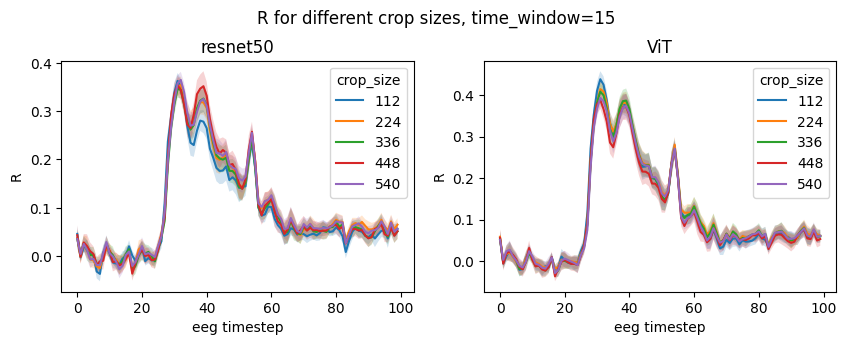

In [90]:
filtered = which_layers.loc[(which_layers["time_window"]==15) & (which_layers["center_crop"]==False),:]
filtered["eeg_time"] = list(np.repeat(np.arange(100)[:,np.newaxis], len(filtered), axis=1).T)
filtered = filtered.explode(["subj_mean", "subj_sem", "eeg_time"])
#g = sns.FacetGrid(data=filtered, col="model_name", height=4, aspect=1.4)
fig, axs = plt.subplots(1,2, figsize=(10,3))
filtered_resnet50 = filtered.loc[filtered["model_name"]=="resnet50",:]
filtered_vit_base = filtered.loc[filtered["model_name"]=="vit_base",:]
sns.lineplot(data=filtered_resnet50, x="eeg_time", y="subj_mean", hue="crop_size", palette="tab10", ax = axs[0])
sns.lineplot(data=filtered_vit_base, x="eeg_time", y="subj_mean", hue="crop_size", palette="tab10", ax = axs[1])
for gs in filtered_resnet50["crop_size"].unique():
    mean = filtered_resnet50.loc[filtered_resnet50["crop_size"]==gs,"subj_mean"].to_numpy().astype('float64')
    sem = filtered_resnet50.loc[filtered_resnet50["crop_size"]==gs,"subj_sem"].to_numpy().astype('float64')
    axs[0].fill_between(np.arange(100),np.array(mean-sem), np.array(mean+sem), alpha=0.2)
    mean = filtered_vit_base.loc[filtered_vit_base["crop_size"]==gs,"subj_mean"].to_numpy().astype('float64')
    sem = filtered_vit_base.loc[filtered_vit_base["crop_size"]==gs,"subj_sem"].to_numpy().astype('float64')
    axs[1].fill_between(np.arange(100),np.array(mean-sem), np.array(mean+sem), alpha=0.2)
#plt.ylim(0.35,0.4)
axs[0].set_xlabel("eeg timestep")
axs[0].set_ylabel("R")
axs[0].set_title("resnet50")
axs[1].set_xlabel("eeg timestep")
axs[1].set_ylabel("R")
axs[1].set_title("ViT")
#g.add_legend()
plt.suptitle("R for different crop sizes, time_window=15", y=1.05)
plt.savefig("../../results/Dwivedi2024EEG/model_comparison/R_for_crop_size_t=15.pdf", format="PDF")

In [16]:
standard_resnet = all_models.groupby("Model").get_group("Standard_ResNet50")
standard_resnet["eeg_time"]=list(np.repeat(np.arange(100)[:,np.newaxis], len(standard_resnet), axis=1).T)

/tmp/ipykernel_2490984/2839699647.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  standard_resnet["eeg_time"]=list(np.repeat(np.arange(100)[:,np.newaxis], len(standard_resnet), axis=1).T)


In [17]:
standard_resnet=standard_resnet.explode(["subj_mean", "subj_sem", "eeg_time"])

/home/yvette/.conda/envs/net2brain_env_editable/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/yvette/.conda/envs/net2brain_env_editable/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/yvette/.conda/envs/net2brain_env_editable/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/yvette/.conda/envs/net2brain_env_editable/lib/p

Text(0.5, 0, 'eeg time step')

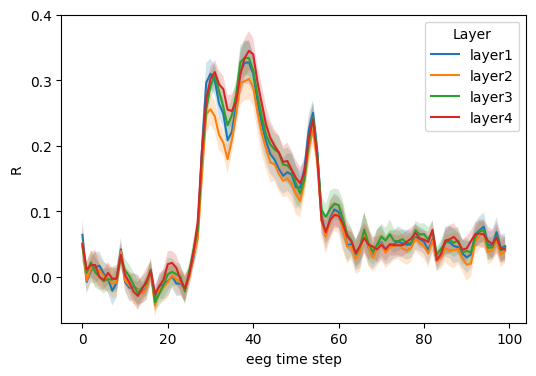

In [20]:
fig, ax = plt.subplots(figsize=(6,4))
sns.lineplot(standard_resnet, x="eeg_time", y="subj_mean", hue="Layer", ax=ax)
for layer in standard_resnet["Layer"].unique():
    mean = standard_resnet.loc[standard_resnet["Layer"]==layer,"subj_mean"].to_numpy().astype('float64')
    sem = standard_resnet.loc[standard_resnet["Layer"]==layer,"subj_sem"].to_numpy().astype('float64')
    ax.fill_between(np.arange(100),np.array(mean-sem), np.array(mean+sem), alpha=0.2)
ax.set_ylabel("R")
ax.set_ylim(-0.07, 0.4)
ax.set_xlabel("eeg time step")

In [ ]:
from net2brain.evaluations.variance_partitioning_analysis import VPA

var_1_df = which_layers.loc[(which_layers["time_window"]==0) & (which_layers["crop_size"]==540),:]
var_2_df = which_layers.loc[(which_layers["time_window"]==0) & (which_layers["crop_size"]!=540),:]
var_3_df = which_layers.loc[(which_layers["time_window"]!=0) & (which_layers["crop_size"]==540),:]
var_4_df = which_layers.loc[(which_layers["time_window"]!=0) & (which_layers["crop_size"]!=540),:]

In [9]:
rdm_dir = "../../tmp/rdms/Dwivedi2024EEG/"
var_1_rdms = [rdm_dir + model_name + "_rdm" + "/RDM_" + best_layer.replace(".", "_")+ ".npz" for model_name, best_layer in list(var_1_df[["Model", "Layer"]].itertuples(index=False, name=None))]
var_2_rdms = [rdm_dir + model_name + "_rdm" + "/RDM_" + best_layer.replace(".", "_")+ ".npz" for model_name, best_layer in list(var_2_df[["Model", "Layer"]].itertuples(index=False, name=None))]
var_3_rdms = [rdm_dir + model_name + "_rdm" + "/RDM_" + best_layer.replace(".", "_")+ ".npz" for model_name, best_layer in list(var_3_df[["Model", "Layer"]].itertuples(index=False, name=None))]
var_4_rdms = [rdm_dir + model_name + "_rdm" + "/RDM_" + best_layer.replace(".", "_")+ ".npz" for model_name, best_layer in list(var_4_df[["Model", "Layer"]].itertuples(index=False, name=None))]


In [10]:
independent_variables = [var_1_rdms, var_2_rdms, var_3_rdms, var_4_rdms]

variable_names = ["no cv, no ts", "cv, no ts", "no cv, ts", "cv, ts"]

dependent_variable_dir = "../../../../data/Dwivedi2024EEG/eeg_rdms_decoding.npy"

#rdm_names = os.listdir(dependent_variable_dir)
#dependent_variable = [dependent_variable_dir + dir_name for dir_name in rdm_names]
#print(rdm_names)
#test=np.load("../../data/Algonauts23_shared_Net2Brain/brain_data/EBA_lh_RDMs.npz")
#print(test["arr_0"].shape)
VPA_eval = VPA(dependent_variable_dir, independent_variables, variable_names)
dataframe = VPA_eval.evaluate(average_models=False)

ValueError: Found input variables with inconsistent numbers of samples: [1225, 50]

In [26]:
varpart_df = pq.read_table("../../results/Dwivedi2024EEG/model_comparison/variance_partitioning/vpa_results.parquet", partitioning=None)
varpart_df=varpart_df.to_pandas()
varpart_df = varpart_df.query("Variable in ['y1234', 'y1', 'y2', 'y3', 'y4']").reset_index(drop=True)

In [27]:
varpart_df.set_index("Variable", inplace=True)
varpart_df.head(5)

,Description,Values,Significance,Color
Variable,,,,
y1,"Unique no cv, no ts","[[0.007335126248836477, 0.0034457390102599073,...","[0.004502078877031943, 0.007750617972166453, 0...",None
y2,"Unique cv, no ts","[[3.4875436827341844e-07, 0.001463035287563197...","[0.012083703058122144, 0.01236643894305505, 0....",None
y3,"Unique no cv, ts","[[0.01794631520111989, 0.003569167379433802, 0...","[0.036835140408642546, 0.0046331015615404545, ...",None
y4,"Unique cv, ts","[[0.006825883541821565, 0.0008917802199093217,...","[0.005630036847616392, 0.024146964296841406, 0...",None
y1234,"Shared Variance no cv, no ts and cv, no ts and...","[[0.0003028182800260959, -0.000649580418965012...","[0.3003013316591793, 0.33613145378315334, 0.22...",None


In [28]:
y1 = np.array(list(varpart_df.loc["y1","Values"]))
y2 = np.array(list(varpart_df.loc["y2","Values"]))
y3 = np.array(list(varpart_df.loc["y3","Values"]))
y4 = np.array(list(varpart_df.loc["y4","Values"]))

In [33]:
from scipy.stats import sem

Text(0.5, 1.0, 'Variance Paritioning Analysis')

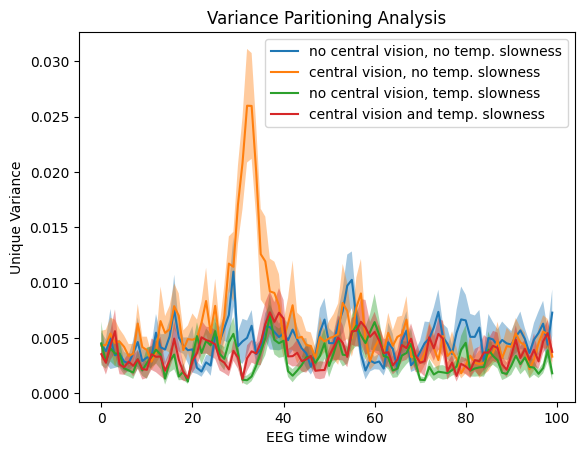

In [37]:
plt.plot(np.mean(y1,axis=0), label="no central vision, no temp. slowness")
plt.fill_between(np.arange(len(np.mean(y1,axis=0))),np.mean(y1,axis=0)-sem(y1,axis=0), np.mean(y1,axis=0)+sem(y1,axis=0),  alpha=0.4)
plt.plot(np.mean(y2,axis=0), label="central vision, no temp. slowness")
plt.fill_between(np.arange(len(np.mean(y2,axis=0))),np.mean(y2,axis=0)-sem(y2,axis=0), np.mean(y2,axis=0)+sem(y2,axis=0),  alpha=0.4)
plt.plot(np.mean(y3,axis=0), label="no central vision, temp. slowness")
plt.fill_between(np.arange(len(np.mean(y3,axis=0))),np.mean(y3,axis=0)-sem(y3,axis=0), np.mean(y3,axis=0)+sem(y3,axis=0),  alpha=0.4)
plt.plot(np.mean(y4,axis=0), label="central vision and temp. slowness")
plt.fill_between(np.arange(len(np.mean(y4,axis=0))),np.mean(y4,axis=0)-sem(y4,axis=0), np.mean(y4,axis=0)+sem(y4,axis=0),  alpha=0.4)
plt.ylabel("Unique Variance")
plt.xlabel("EEG time window")
plt.legend()
plt.title("Variance Paritioning Analysis")

In [29]:
np.array(varpart_df.loc["y1","Values"]).shape

(16,)

In [ ]:
"../../tmp/rdms/Dwivedi2024EEG/resnet50_t=0_gs=540_2dbc5f1b_rdm/RDM_backbone_layer4.npz"

In [21]:
np.load("../../../../data/Dwivedi2024EEG/eeg_rdms_decoding.npy").shape

(16, 100, 50, 50)

In [25]:
eeg_npy = np.load("../../../../data/Dwivedi2024EEG/rdms_npy/eeg_rdms_decoding.npy")

In [26]:
for i in range(eeg_npy.shape[0]):
    np.save(f"../../../../data/Dwivedi2024EEG/rdms_npy/subj_{i}_eeg_rdms_decoding.npy", eeg_npy[i,:,:,:])

In [16]:
import pyarrow as pa
import pyarrow.parquet as pq
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator

In [17]:
filepath_rsa="../../results/872_shared_total/model_comparison/rsa_model_comp_e4225132.parquet"
filepath_reg="../../results/872_shared_total/model_comparison/reg_model_comp_e4225132.parquet"
comp_table_rsa = pq.read_table(filepath_rsa, partitioning=None)
comp_table_reg = pq.read_table(filepath_reg, partitioning=None)
comp_df_rsa = comp_table_rsa.to_pandas()
comp_df_reg = comp_table_reg.to_pandas()
comp_df_rsa.reset_index(inplace=True, drop=True)
comp_df_reg.reset_index(inplace=True, drop=True)

In [18]:
for roi in comp_df_reg["ROI"].unique():
    if roi.startswith("V3"):
        continue
    plot_df_rsa = comp_df_rsa.loc[comp_df_rsa["ROI"]==roi, :]
    layers = plot_df_rsa["Layer"].str.split(".").apply(lambda x: x[-1])
    plot_df_rsa=plot_df_rsa.explode("R_array")
    plot_df_rsa["R_array"] = pd.to_numeric(plot_df_rsa["R_array"])
    fig, ax = plt.subplots(figsize=(8,4))
    sns.barplot(data=plot_df_rsa, x="Model", y="R_array", errorbar="se", capsize=0.2)
    ax.set_ylabel("R")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_title("RSA: R for different models, ROI: " + roi)

    pairs = [
        #("Standard_ResNet50", "resnet50_t=0_gs=224_c55ac28d"),
        #("Standard_ResNet50", "resnet50_t=15_gs=224_7c077e46"),
        #("Timm_vit_base_patch16_224", "vit_base_t=0_gs=224_29bdaddc"),
        #("Timm_vit_base_patch16_224", "vit_base_t=15_gs=224_6c762d28")
        ("moco_resnet50_imagenet", "resnet50_t=0_gs=224_c55ac28d"),
        ("moco_vit_base_imagenet", "vit_base_t=0_gs=224_29bdaddc")
    ]

    annotator = Annotator(ax, pairs, data=plot_df_rsa, x="Model", y="R_array")
    annotator.configure(test="t-test_paired", text_format="star", loc="inside")
    annotator.apply_and_annotate()

    for bar, label in zip(ax.patches, layers):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height()-0.07,
            str(label),
            ha='center',
            va='bottom'
        )

    plt.savefig("../../results/872_shared_total/model_comparison/imagenet_comparison/rsa_imagenet_comp_"+roi+".pdf", format="PDF", bbox_inches="tight")
    plt.close()

    plot_df_reg = comp_df_reg.loc[comp_df_reg["ROI"]==roi, :]
    layers = plot_df_reg["Layer"].str.split(".").apply(lambda x: x[-1])
    plot_df_reg=plot_df_reg.explode("R_array")
    plot_df_reg["R_array"] = pd.to_numeric(plot_df_reg["R_array"])
    
    fig, ax = plt.subplots(figsize=(8,4))
    sns.barplot(data=plot_df_reg, x="Model", y="R_array", errorbar="se", capsize=0.2)
    ax.set_ylabel("R")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_title("Regression: R for different models, ROI: " + roi)



    pairs = [
        ("moco_resnet50_imagenet", "resnet50_t=0_gs=224_c55ac28d"),
        #("moco_resnet50_imagenet", "resnet50_t=15_gs=224_7c077e46"),
        #("Standard_ResNet50", "resnet50_t=0_gs=224_c55ac28d"),
        #("Standard_ResNet50", "resnet50_t=15_gs=224_7c077e46"),
        #("Timm_vit_base_patch16_224", "vit_base_t=0_gs=224_29bdaddc"),
        #("Timm_vit_base_patch16_224", "vit_base_t=15_gs=224_6c762d28"),
        ("moco_vit_base_imagenet", "vit_base_t=0_gs=224_29bdaddc"),
        #("moco_vit_base_imagenet", "vit_base_t=15_gs=224_6c762d28")
    ]

    annotator = Annotator(ax, pairs, data=plot_df_reg, x="Model", y="R_array")
    annotator.configure(test="t-test_paired", text_format="star", loc="inside")
    annotator.apply_and_annotate()
    for bar, label in zip(ax.patches, layers):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height()-0.07,
            str(label),
            ha='center',
            va='bottom'
        )
    plt.savefig("../../results/872_shared_total/model_comparison/imagenet_comparison/reg_imagenet_comp_"+roi+".pdf", format="PDF", bbox_inches="tight")
    plt.close()
        

/tmp/ipykernel_2042741/1973411539.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

moco_resnet50_imagenet vs. resnet50_t=0_gs=224_c55ac28d: t-test paired samples, P_val:8.258e-01 t=2.285e-01
moco_vit_base_imagenet vs. vit_base_t=0_gs=224_29bdaddc: t-test paired samples, P_val:1.854e-06 t=1.440e+01


/tmp/ipykernel_2042741/1973411539.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

moco_resnet50_imagenet vs. resnet50_t=0_gs=224_c55ac28d: t-test paired samples, P_val:6.490e-08 t=2.346e+01
moco_vit_base_imagenet vs. vit_base_t=0_gs=224_29bdaddc: t-test paired samples, P_val:1.086e-05 t=1.108e+01


/tmp/ipykernel_2042741/1973411539.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


...

/tmp/ipykernel_2042741/1973411539.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

moco_resnet50_imagenet vs. resnet50_t=0_gs=224_c55ac28d: t-test paired samples, P_val:2.614e-05 t=9.700e+00
moco_vit_base_imagenet vs. vit_base_t=0_gs=224_29bdaddc: t-test paired samples, P_val:3.659e-05 t=9.214e+00


/tmp/ipykernel_2042741/1973411539.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

moco_resnet50_imagenet vs. resnet50_t=0_gs=224_c55ac28d: t-test paired samples, P_val:2.762e-03 t=-4.511e+00
moco_vit_base_imagenet vs. vit_base_t=0_gs=224_29bdaddc: t-test paired samples, P_val:7.642e-04 t=5.663e+00
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

moco_resnet50_imagenet vs. resnet50_t=0_gs=224_c55ac28d: t-test paired samples, P_val:2.872e-02 t=2.745e+00
moco_vit_base_imagenet vs. vit_base_t=0_gs=224_29bdaddc: t-test paired samples, P_val:1.868e-02 t=3.046e+00


/tmp/ipykernel_2042741/1973411539.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


In [22]:
plot_df_rsa["Layer"].str.split(".").apply(lambda x: x[-1])

18     layer4
18     layer4
18     layer4
18     layer4
18     layer4
        ...  
151         6
151         6
151         6
151         6
151         6
Name: Layer, Length: 64, dtype: object

In [21]:
plot_df_rsa = comp_df_rsa.loc[comp_df_rsa["ROI"]=="V3d", :]
layers = plot_df_rsa["Layer"].str.split(".").apply(lambda x: x[-1])
plot_df_rsa=plot_df_rsa.explode("R_array")
plot_df_rsa["R_array"] = pd.to_numeric(plot_df_rsa["R_array"])

/tmp/ipykernel_2042741/2741933456.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

moco_resnet50_imagenet vs. resnet50_t=0_gs=224_c55ac28d: t-test paired samples, P_val:5.097e-01 t=6.946e-01
moco_vit_base_imagenet vs. vit_base_t=0_gs=224_29bdaddc: t-test paired samples, P_val:2.439e-05 t=9.803e+00


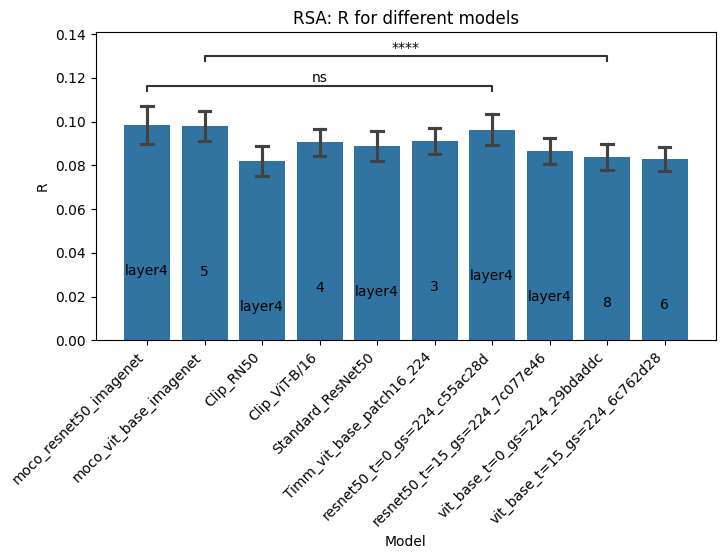

In [22]:
fig, ax = plt.subplots(figsize=(8,4))
sns.barplot(data=plot_df_rsa, x="Model", y="R_array", errorbar="se", capsize=0.2)
ax.set_ylabel("R")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_title("RSA: R for different models")

pairs = [
    ("moco_resnet50_imagenet", "resnet50_t=0_gs=224_c55ac28d"),
    #("moco_resnet50_imagenet", "resnet50_t=15_gs=224_7c077e46"),
    #("Standard_ResNet50", "resnet50_t=0_gs=224_c55ac28d"),
    #("Standard_ResNet50", "resnet50_t=15_gs=224_7c077e46"),
    #("Timm_vit_base_patch16_224", "vit_base_t=0_gs=224_29bdaddc"),
    #("Timm_vit_base_patch16_224", "vit_base_t=15_gs=224_6c762d28"),
    ("moco_vit_base_imagenet", "vit_base_t=0_gs=224_29bdaddc")
    #("moco_vit_base_imagenet", "vit_base_t=15_gs=224_6c762d28")
]


for bar, label in zip(ax.patches, layers):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height()-0.07,
        str(label),
        ha='center',
        va='bottom'
    )

annotator = Annotator(ax, pairs, data=plot_df_rsa, x="Model", y="R_array")
annotator.configure(test="t-test_paired", text_format="star", loc="inside")
annotator.apply_and_annotate()
plt.savefig("../../results/872_shared_total/model_comparison/imagenet_comparison/rsa_imagenet_comp_V3d.pdf", format="PDF", bbox_inches="tight")

In [27]:
plot_df_reg = comp_df_reg.loc[comp_df_reg["ROI"]=="V3d_rh", :]
layers = plot_df_reg["Layer"].str.split(".").apply(lambda x: x[-1])
plot_df_reg=plot_df_reg.explode("R_array")
plot_df_reg["R_array"] = pd.to_numeric(plot_df_reg["R_array"])

/tmp/ipykernel_2042741/3681185454.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

moco_resnet50_imagenet vs. resnet50_t=0_gs=224_c55ac28d: t-test paired samples, P_val:5.097e-01 t=6.946e-01
moco_vit_base_imagenet vs. vit_base_t=0_gs=224_29bdaddc: t-test paired samples, P_val:2.439e-05 t=9.803e+00


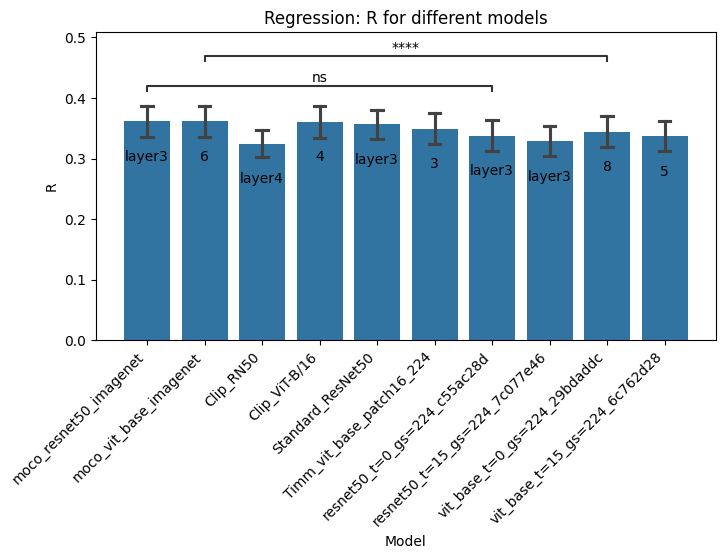

In [28]:
fig, ax = plt.subplots(figsize=(8,4))
sns.barplot(data=plot_df_reg, x="Model", y="R_array", errorbar="se", capsize=0.2)

ax.set_ylabel("R")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_title("Regression: R for different models")

pairs = [
    ("moco_resnet50_imagenet", "resnet50_t=0_gs=224_c55ac28d"),
    #("moco_resnet50_imagenet", "resnet50_t=15_gs=224_7c077e46"),
    #("Standard_ResNet50", "resnet50_t=0_gs=224_c55ac28d"),
    #("Standard_ResNet50", "resnet50_t=15_gs=224_7c077e46"),
    #("Timm_vit_base_patch16_224", "vit_base_t=0_gs=224_29bdaddc"),
    #("Timm_vit_base_patch16_224", "vit_base_t=15_gs=224_6c762d28"),
    ("moco_vit_base_imagenet", "vit_base_t=0_gs=224_29bdaddc")
    #("moco_vit_base_imagenet", "vit_base_t=15_gs=224_6c762d28")
]


for bar, label in zip(ax.patches, layers):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height()-0.07,
        str(label),
        ha='center',
        va='bottom'
    )

annotator = Annotator(ax, pairs, data=plot_df_rsa, x="Model", y="R_array")
annotator.configure(test="t-test_paired", text_format="star", loc="inside")
annotator.apply_and_annotate()
plt.savefig("../../results/872_shared_total/model_comparison/imagenet_comparison/reg_imagenet_comp_V3d_rh.pdf", format="PDF", bbox_inches="tight")

In [15]:
comp_df_reg["Model"].unique()

array(['moco_resnet50_imagenet', 'moco_vit_base_imagenet',
       'Standard_ResNet50', 'Timm_vit_base_patch16_224',
       'resnet50_t=0_gs=224_c55ac28d', 'resnet50_t=15_gs=224_7c077e46',
       'vit_base_t=0_gs=224_29bdaddc', 'vit_base_t=15_gs=224_6c762d28'],
      dtype=object)

In [30]:
clip_data_table = pq.read_table("../../results/872_shared_total/Clip_ViT-B_16/eval_df_rsa.parquet", partitioning=None)
clip_data = clip_data_table.to_pandas()

In [35]:
clip_data.reset_index(inplace=True, drop=True)
max_idx = clip_data.groupby(["ROI"])["R"].idxmax()

In [36]:
clip_data.loc[max_idx,:]

,ROI,Layer,Model,R,%R,R_array,Significance,SEM,LNC,UNC
201,EBA_lh,visual.transformer.resblocks.4,Clip_ViT-B/16,0.120619,34.912334,"[0.1551979487176772, 0.13814071088095475, 0.13...",3.706285e-06,0.009277,0.345492,0.473244
366,EBA_rh,visual.transformer.resblocks.4,Clip_ViT-B/16,0.118888,30.791240,"[0.12517945276153164, 0.13225334392592322, 0.1...",8.443085e-07,0.007356,0.386108,0.505474
300,FBA-2_rh,visual.transformer.resblocks.4,Clip_ViT-B/16,0.088430,38.986162,"[0.1223989276773951, 0.133936289579815, 0.0726...",6.253942e-05,0.010424,0.226824,0.374752
91,FFA-1_lh,visual.transformer.resblocks.4,Clip_ViT-B/16,0.099828,49.374676,"[0.1281399142657241, 0.11609727837401454, 0.10...",1.835075e-06,0.006921,0.202185,0.356356
124,FFA-1_rh,visual.transformer.resblocks.4,Clip_ViT-B/16,0.099897,37.994566,"[0.08220822108413427, 0.12215361618641114, 0.0...",2.260138e-06,0.007142,0.262924,0.409085
344,FFA-2_rh,visual.transformer.resblocks.4,Clip_ViT-B/16,0.079813,59.780207,"[0.12636281589949064, 0.12818771497943177, 0.0...",1.442764e-03,0.015734,0.133510,0.284622
322,OFA_lh,visual.transformer.resblocks.4,Clip_ViT-B/16,0.095435,88.886270,"[0.09520694708326435, 0.06828376671881542, 0.0...",1.083103e-05,0.008612,0.107368,0.267605
223,OFA_rh,visual.transformer.resblocks.4,Clip_ViT-B/16,0.090823,87.466883,"[0.09591132635752521, 0.07318013284093744, 0.1...",1.175083e-04,0.011815,0.103837,0.261838
256,OPA_lh,visual.transformer.resblocks.4,Clip_ViT-B/16,0.145723,105.423937,"[0.21167525244234273, 0.17699206833113812, 0.1...",2.135443e-05,0.014568,0.138226,0.299318
58,OPA_rh,visual.transformer.resblocks.4,Clip_ViT-B/16,0.150547,94.503128,"[0.21040819782190204, 0.16884593262516623, 0.1...",1.506981e-05,0.014278,0.159304,0.318830


In [37]:
groups = clip_data.groupby("ROI")

In [39]:
groups.get_group("PPA_lh")

,ROI,Layer,Model,R,%R,R_array,Significance,SEM,LNC,UNC
11,PPA_lh,visual.transformer.resblocks.1,Clip_ViT-B/16,0.052472,30.893951,"[0.056419627458145, 0.0598355301095228, 0.0564...",6.323754e-07,0.003112,0.169846,0.329043
12,PPA_lh,visual.transformer.resblocks.2,Clip_ViT-B/16,0.093301,54.932669,"[0.09497059987975347, 0.10852517725667413, 0.0...",9.566598e-07,0.005879,0.169846,0.329043
13,PPA_lh,visual.transformer.resblocks.3,Clip_ViT-B/16,0.134931,79.443238,"[0.1329295158929671, 0.15947146044761204, 0.13...",5.538551e-07,0.007850,0.169846,0.329043
14,PPA_lh,visual.transformer.resblocks.4,Clip_ViT-B/16,0.158057,93.059113,"[0.1618511927907658, 0.18291459189075848, 0.15...",4.204538e-07,0.008833,0.169846,0.329043
15,PPA_lh,visual.transformer.resblocks.5,Clip_ViT-B/16,0.124534,73.322074,"[0.12911660133292194, 0.14578867702068085, 0.1...",3.776003e-07,0.006852,0.169846,0.329043
16,PPA_lh,visual.transformer.resblocks.6,Clip_ViT-B/16,0.067640,39.824095,"[0.06962137383537086, 0.07745985936804807, 0.0...",3.313177e-07,0.003651,0.169846,0.329043
17,PPA_lh,visual.transformer.resblocks.7,Clip_ViT-B/16,0.041823,24.623887,"[0.04397062011621316, 0.04877957436285983, 0.0...",9.757309e-07,0.002643,0.169846,0.329043
18,PPA_lh,visual.transformer.resblocks.8,Clip_ViT-B/16,0.045052,26.525184,"[0.046690065525253274, 0.05076155712193963, 0....",8.143294e-07,0.002773,0.169846,0.329043
19,PPA_lh,visual.transformer.resblocks.9,Clip_ViT-B/16,0.045089,26.546785,"[0.04611251063305033, 0.04972989538856131, 0.0...",1.000073e-06,0.002860,0.169846,0.329043
20,PPA_lh,visual.transformer.resblocks.10,Clip_ViT-B/16,0.048957,28.824417,"[0.050991461905187614, 0.05417838506538525, 0....",5.775403e-07,0.002866,0.169846,0.329043


In [8]:
import cv2

In [27]:
os.listdir("../../../../data/BOLDmoments/BoldMoments/stimuli_test/")

FileNotFoundError: [Errno 2] No such file or directory: '../../../../data/BOLDmoments/BoldMoments/stimuli_test/'

In [15]:
cap = cv2.VideoCapture("../../../../data/BOLDmoments/BoldMoments_incomplete/stimuli_test/1012.mp4")

In [16]:
frames = cap.get(cv2.CAP_PROP_FRAME_COUNT)
print(frames)
fps = cap.get(cv2.CAP_PROP_FPS)
print(fps)
print(frames/fps)

72.0
23.976023976023978
3.0029999999999997


6.0

In [71]:
import pickle

In [78]:
with open("../../../../data/BOLDmoments/ds005165/derivatives/versionA/MNI152/prepared_data/prepared_reliable_pkl/TRavg56789/sub-01/EBA_TRavg-56789_reliable.pkl", 'rb') as f:
    data =pickle.load(f)

In [79]:
data.keys()

dict_keys(['noise_ceiling', 'p_values', 'train_data_reliable', 'test_data_reliable'])

In [81]:
data["train_data_reliable"].shape

(1000, 3, 441)

In [59]:
import numpy as np
test = np.load("../../../../data/BOLDmoments/BoldMoments_incomplete/fmri/sub-01/train/EBA_train.npy")

In [53]:
os.listdir("../../../../data/BOLDmoments/BoldMoments_incomplete/fmri/sub-01/")

['test', 'train', '.DS_Store']

In [60]:
test.shape

(1000, 324)

In [56]:
3*81

243

In [2]:
import os
import numpy as np
test=np.load("../../../../data/BOLDmoments/rdms/V3v_RDMs.npz")
#os.listdir("../../../../data/BOLDmoments/rdms")
print(test["arr_0"].shape)

(10, 1102, 1102)


In [ ]:
test=np.load("../../../../data/BOLDmoments/ds005165/derivatives/versionA/MNI152/prepared_data/prepared_reliable_pkl/TRavg56789/sub-07/EBA_TRavg-56789_reliable.pkl", allow_pickle=True)

In [14]:
from net2brain.rdm.feature_iterator import nsorted

In [15]:
stimuli_test = os.listdir("../../../../home/data/BOLDmoments/stimuli_combined")

In [17]:
nsorted(stimuli_test)[-1]

'1102.mp4'

In [2]:
import numpy as np
test_features = np.load("../../tmp/features/resnet50_t=0_gs=112_0955ffe8_feat/0001.npz")

In [3]:
test_features["backbone.layer1"].shape

(1, 1, 5, 256, 56, 56)

In [7]:
from PIL import Image

img = Image.open("../../../../data/Algonauts23_shared_Net2Brain/images/train-5892_nsd-43689.png")

print(img.size)

(425, 425)


In [5]:
test=np.load("../../tmp/rdms/BOLDmoments/resnet50_t=0_gs=112_313ee068_rdm/RDM_backbone_layer1.npz")

In [7]:
test["rdm"]

array([0.61491114, 0.57915495, 0.56275007, ..., 0.58582385, 0.65223443,
       0.61047393], shape=(606651,))

In [8]:
from scipy.spatial.distance import squareform

In [9]:
squareform(test["rdm"])

array([[0.        , 0.61491114, 0.57915495, ..., 0.61193731, 0.55874603,
        0.63371632],
       [0.61491114, 0.        , 0.60042483, ..., 0.63090171, 0.56815597,
        0.63841721],
       [0.57915495, 0.60042483, 0.        , ..., 0.59797747, 0.55984593,
        0.60597146],
       ...,
       [0.61193731, 0.63090171, 0.59797747, ..., 0.        , 0.58582385,
        0.65223443],
       [0.55874603, 0.56815597, 0.55984593, ..., 0.58582385, 0.        ,
        0.61047393],
       [0.63371632, 0.63841721, 0.60597146, ..., 0.65223443, 0.61047393,
        0.        ]], shape=(1102, 1102))

In [63]:
test_brain = np.load("../../../../data/BOLDmoments/rdms/TOS_RDMs.npz")

In [67]:
test_brain["arr_0"].shape

(10, 1102, 1102)

In [9]:
from net2brain.rdm.dist_utils import dist
test_fmri = np.load("../../../../data/BOLDmoments/ds005165/derivatives/versionA/MNI152/prepared_data/prepared_reliable_pkl/TRavg56789/sub-01/EBA_TRavg-56789_reliable.pkl", allow_pickle=True)
test_avg_train = test_fmri["train_data_reliable"].mean(axis=1)
test_avg_test = test_fmri["test_data_reliable"].mean(axis=1)
test_data = np.concatenate([test_avg_train, test_avg_test], axis=0)
test_rdm = dist(test_data, metric="correlation", chunk_size=None, verbose=True, device='cpu')


In [11]:
test_fmri["train_data_reliable"].shape

(1000, 3, 441)

In [12]:
test_fmri_2 = np.load("../../../../data/BOLDmoments/BoldMoments_incomplete/fmri/sub-01/train/EBA_train.npy")
print(test_fmri_2.shape)

(1000, 324)


In [ ]:
test_fmri_2 = np.load("../../../../data/BOLDmoments/BoldMoments_incomplete/")

In [86]:
test_fmri

{'noise_ceiling': array([], dtype=float64),
 'p_values': array([], dtype=float64),
 'train_data_reliable': array([], shape=(1000, 3, 0), dtype=float64),
 'test_data_reliable': array([], shape=(102, 10, 0), dtype=float64)}

In [ ]:

print(test_avg_test.shape)

(102, 81)


In [75]:
from net2brain.rdm.dist_utils import dist

In [ ]:
print(test_data.shape)

(1102, 81)


In [82]:
test_rdm.numpy().shape

(1102, 1102)

In [42]:
os.listdir("../../../../data/BOLDmoments/ds005165/derivatives/versionA/MNI152/prepared_data/prepared_reliable_pkl/TRavg56789/sub-02")

['STS_TRavg-56789_reliable.pkl',
 'PFop_TRavg-56789_reliable.pkl',
 'FFA_TRavg-56789_reliable.pkl',
 'TOS_TRavg-56789_reliable.pkl',
 'hV4_TRavg-56789_reliable.pkl',
 'V3d_TRavg-56789_reliable.pkl',
 'V2v_TRavg-56789_reliable.pkl',
 'V3v_TRavg-56789_reliable.pkl',
 'IPS1-2-3_TRavg-56789_reliable.pkl',
 'V2d_TRavg-56789_reliable.pkl',
 'LOC_TRavg-56789_reliable.pkl',
 'BA2_TRavg-56789_reliable.pkl',
 'WB_TRavg-56789_reliable.pkl',
 'IPS0_TRavg-56789_reliable.pkl',
 'V1v_TRavg-56789_reliable.pkl',
 'PPA_TRavg-56789_reliable.pkl',
 'V1d_TRavg-56789_reliable.pkl',
 'V3ab_TRavg-56789_reliable.pkl',
 'EBA_TRavg-56789_reliable.pkl',
 'OFA_TRavg-56789_reliable.pkl',
 '7AL_TRavg-56789_reliable.pkl',
 'RSC_TRavg-56789_reliable.pkl',
 'PFt_TRavg-56789_reliable.pkl']

In [38]:
import matplotlib.pyplot as plt
test_brain["arr_0"][3,:,:]

array([[-2.22044605e-16,  1.25654904e+00,  1.43367780e+00, ...,
         1.58356371e+00,  1.42944262e+00,  1.09401089e+00],
       [ 1.25654904e+00, -2.22044605e-16,  8.97529681e-01, ...,
         9.89753762e-01,  4.53459864e-01,  1.32540322e+00],
       [ 1.43367780e+00,  8.97529681e-01,  0.00000000e+00, ...,
         7.98241432e-01,  6.85263201e-01,  8.19967498e-01],
       ...,
       [ 1.58356371e+00,  9.89753762e-01,  7.98241432e-01, ...,
        -2.22044605e-16,  4.76308127e-01,  8.46671146e-01],
       [ 1.42944262e+00,  4.53459864e-01,  6.85263201e-01, ...,
         4.76308127e-01,  2.22044605e-16,  1.34255944e+00],
       [ 1.09401089e+00,  1.32540322e+00,  8.19967498e-01, ...,
         8.46671146e-01,  1.34255944e+00, -2.22044605e-16]],
      shape=(1102, 1102))

In [ ]:
import os
os.listdir("../../../../data/BOLDmoments/rdms/TOS_RDMs.npz")

NotADirectoryError: [Errno 20] Not a directory: '../../../../data/BOLDmoments/rdms/V3v_RDMs.npz'

In [24]:
import pyarrow.parquet as pq
test_results = pq.read_table("../../results/BOLDmoments/resnet50_t=0_gs=112_313ee068/eval_df_rsa.parquet", partitioning=None)
test_df = test_results.to_pandas()

In [34]:
test_df.loc[test_df["R"].isna(),"R_array"].iloc[6]

array([0.02093341, 0.02628246,        nan, 0.00964053, 0.01805691,
       0.02052328, 0.01849912, 0.00895559, 0.01260683, 0.02384921])

In [72]:
import os
import sys
import numpy as np
from net2brain.rdm_creation import RDMCreator
from net2brain.rdm.dist import correlation
from net2brain.rdm.dist_utils import dist
from pathlib import Path
#sys.path.insert(0, str(Path(__file__).resolve().parents[0]))
from .utils import get_shared_rois_BOLDmoments


rdm_path = "../../data/BOLDmoments/rdms/"
travg56789_dir = "../../data/BOLDmoments/ds005165/derivatives/versionA/MNI152/prepared_data/prepared_reliable_pkl/TRavg56789"
subj_dir_list = os.listdir(travg56789_dir)
roi_list = get_shared_rois_BOLDmoments()
for roi in roi_list:
    rdm_list = []
    for subj_dir in subj_dir_list:
        data = np.load(os.path.join(travg56789_dir, subj_dir, roi + "_TRavg-56789_reliable.pkl" ), allow_pickle=True)
        train_data = np.mean(data["train_data_reliable"], axis=1)
        test_data = np.mean(data["test_data_reliable"], axis=1)

        combined_data = np.concatenate([train_data, test_data], axis = 0)
        rdm = dist(combined_data, metric="correlation", chunk_size=None, verbose=True, device='cpu')
        if np.all(rdm)==rdm[0,0]:
            print(subj_dir)
            print(roi)
            print("-------------")
        rdm_list.append(rdm)
    all_subj_rdm = np.stack(rdm_list, axis = 0)
    #np.savez(os.path.join(rdm_path, roi + "_RDMs.npz"), all_subj_rdm)

ImportError: attempted relative import with no known parent package

In [1]:
import pyarrow.parquet as pq

In [2]:
test_table = pq.read_table("../../results/BOLDmoments/model_comparison/rsa_model_comp_84e5c468.parquet", partitioning=None)

In [4]:
test_df=test_table.to_pandas()

In [6]:
test_df

,ROI,Model,Layer,R,R_array,SEM,Significance,%R,LNC,UNC,model_name,time_window,crop_size,center_crop
0,7AL,resnet50_t=0_gs=112_313ee068,backbone.layer4,0.012529,"[0.01062102211098374, 0.013943449258203426, 0....",0.002041,1.711430e-04,15.980281,0.080091,0.343502,resnet50,0,112,False
1,BA2,resnet50_t=0_gs=112_313ee068,backbone.layer4,0.014139,"[0.006508394380265462, 0.02174302940519271, 0....",0.002542,3.507464e-04,16.499534,0.085954,0.345547,resnet50,0,112,False
2,BMDgeneral,resnet50_t=0_gs=112_313ee068,backbone.layer4,0.112693,"[0.1446605808145151, 0.10464554651780446, 0.07...",0.006801,4.738277e-08,24.698189,0.456281,0.580288,resnet50,0,112,False
3,EBA,resnet50_t=0_gs=112_313ee068,backbone.layer4,0.076230,"[0.11064426209556905, 0.06542491681056331, 0.0...",0.005988,4.644868e-07,18.422038,0.412239,0.547333,resnet50,0,112,False
4,FFA,resnet50_t=0_gs=112_313ee068,backbone.layer4,0.064837,"[0.10625622836919511, 0.053018027567982226, 0....",0.005235,5.881597e-07,23.231159,0.284845,0.465105,resnet50,0,112,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,V3ab,vit_base_t=15_gs=224_f75327b1,backbone.blocks.6,0.057420,"[0.07117891656718636, 0.0844009052061189, 0.03...",0.004938,1.005533e-06,24.502421,0.235089,0.432335,vit_base,15,224,False
96,V3d,vit_base_t=15_gs=224_f75327b1,backbone.blocks.6,0.059450,"[0.06655064364107727, 0.0643742314874739, 0.05...",0.003075,1.223522e-08,29.017002,0.205781,0.414686,vit_base,15,224,False
97,V3v,vit_base_t=15_gs=224_f75327b1,backbone.blocks.6,0.050044,"[0.052990681876041806, 0.04264373698256782, 0....",0.004514,1.507142e-06,27.143039,0.185477,0.401430,vit_base,15,224,False
98,WB,vit_base_t=15_gs=224_f75327b1,backbone.blocks.6,0.058228,"[0.08054902400389148, 0.05992166531526036, 0.0...",0.004447,3.652863e-07,36.055302,0.161498,0.384604,vit_base,15,224,False


In [5]:
test_df["ROI"].unique()

array(['7AL', 'BA2', 'BMDgeneral', 'EBA', 'FFA', 'IPS0', 'IPS1-2-3',
       'LOC', 'MT', 'OFA', 'PFop', 'PFt', 'PPA', 'RSC', 'STS', 'TOS',
       'V1d', 'V1v', 'V2d', 'V2v', 'V3ab', 'V3d', 'V3v', 'WB', 'hV4'],
      dtype=object)

In [7]:
import plotting

ModuleNotFoundError: No module named 'utils'